# EMG Processing Tutorial
Author: Johan A. ACHARD (2026)

It follows three main steps:

1. **From raw EMG recordings to preprocessed data**: extract and preprocess the EMG signal and correct response-marker timing using behavioral reaction times.
2. **Automatic EMG onset/offset detection**: detect EMG bursts and estimate their onset and offset.
3. **Visual inspection and manual correction**: inspect the automatically detected markers, manually correct them when necessary, and save the final validated event files.

### Pipeline overview

The **EMG signal and event markers are first processed separately and then combined during segmentation and onset/offset detection before manual validation**.

- The **EMG signal** is extracted, bipolar-referenced, filtered, and saved as a `.fif` file.
- The **events** are extracted from the original recording, and response-marker timing is corrected using behavioral reaction times.
- The corrected events are then used to segment the EMG signal into stimulus-locked trials.
- Automatic EMG onset/offset markers are added to the event structure and subsequently visually inspected and manually corrected when necessary.

The EMG processing functions used in this tutorial are largely based on the MyOnset toolbox developed by L. Spieser. The original toolbox is available at: https://github.com/lspieser/myonset

### Recommendations
Recommended output structure:

```text
EMG_processing/
├── processed_data_STEP1/
│   ├── EMG_signals/
│   └── triggers/
└── processed_data_STEP2/
    ├── segmented/
    └── continuous/
```


Remember your triggers, for example in this example:

| Event type | Codes |
|---|---|
| Stimulus onset | `11,12,13,  14,15,16` |
| Responses trigger | `100, 101, 102, 103, 200, 201, 202, 203` |
| No response / too late | `250` |
| EMG onset marker | `350` |
| EMG offset marker | `351` |

In [1]:
# Import library
import os
import sys 
current = os.path.join(os.getcwd()) # find current file
os.chdir(os.path.join(current, "toolbox_EMG"))

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import arviz as az
import mne
import copy
import emgTools as emg
import evtTools as evt
from Events import Events
import vizEMG
import useMne
import warnings


# Hide warnings
warnings.filterwarnings("ignore")
mne.set_log_level('ERROR')  

az.style.use('arviz-white')
np.set_printoptions(5, suppress=True) # afficher les nombre a 5decimal
# if need for visualisation : pip install PyQt5-tools

## 1. From raw EMG signal to rectified
### 1.1. Load `.bdf` file

First, selected subject and load corresponding bdf data file, then anonymized, and save in fif file.

In [2]:
# # ------ Select subject and load data ------
# nameSubj = 'subject_example'

# data_fname = os.path.join(current, 'data_example', 'behavior_EMG_data', nameSubj + '.bdf')
# raw = mne.io.read_raw_bdf(data_fname, preload=True, verbose=False)
# mne.io.anonymize_info(raw.info)

# # Save anonymized example
# out_fname = os.path.join(current, "data_example", "behavior_EMG_data", nameSubj + ".fif")
# raw.save(out_fname, overwrite=True, verbose=False)
# print("BDF loaded and anonymized.")

In [ ]:
# -- Load anonymized fif file ---
nameSubj = 'subject_example'
out_fname = os.path.join(current, "data_example", "behavior_EMG_data", nameSubj + ".fif")
raw = mne.io.read_raw_fif(out_fname, preload=True, verbose=False)

# Info (rate and channel names)
sf = raw.info['sfreq']#sampling rate
ch_names = raw.ch_names#channel names
print ("successful EMG data loading")

raw

successful EMG data loading


<Raw | subject_example.fif, 5 x 4162560 (4065.0 s), ~158.8 MiB, data loaded>

Now, we can extract triggers events from bdf file. The first column is the sample of the event (1024 samples = 1 second) since recording onset, second column is trigger channel (0 if left hand, 1 if right hand, -1 else) ; and third is corresponding experimentale trigger (either stimulus or response).

In [4]:
raw_events = mne.find_events(raw) 
raw_events  # shape (time in sample; channel 0 if left and 1 right, triggers)

array([[    572,   65536,   65541],
       [  22413,       0,      15],
       [  23435,       0,       1],
       ...,
       [4051338,       0,       1],
       [4058510,       0,     111],
       [4059636,       0,     101]], shape=(1281, 3))

You can check number ot trials, conditions, etc., if you want:

In [5]:
count = np.count_nonzero(np.isin(raw_events[:, 2], [100, 101, 102, 103, 200, 201, 202, 203, 250]))
print(f'{count}/240 trials found.')

240/240 trials found.


### 1.2. Extract EMG channels, compute bipolar derivation and apply filter

**Goal**: convert the raw BDF file into a clean two-channel EMG signal.

1. Extract raw trigger events.
2. Keep `EXG1`, `EXG2`, `EXG3`, and `EXG4`.
3. Compute bipolar derivations:
   - `EMGL = EXG1 - EXG2`
   - `EMGR = EXG3 - EXG4`
4. Apply a 10 Hz high-pass filter.
5. Save the filtered bipolar signal as `{subject}_EMGstep1.fif`.

The plot below is a quality check: it compares the unfiltered bipolar EMG with the filtered EMG over a short segment.

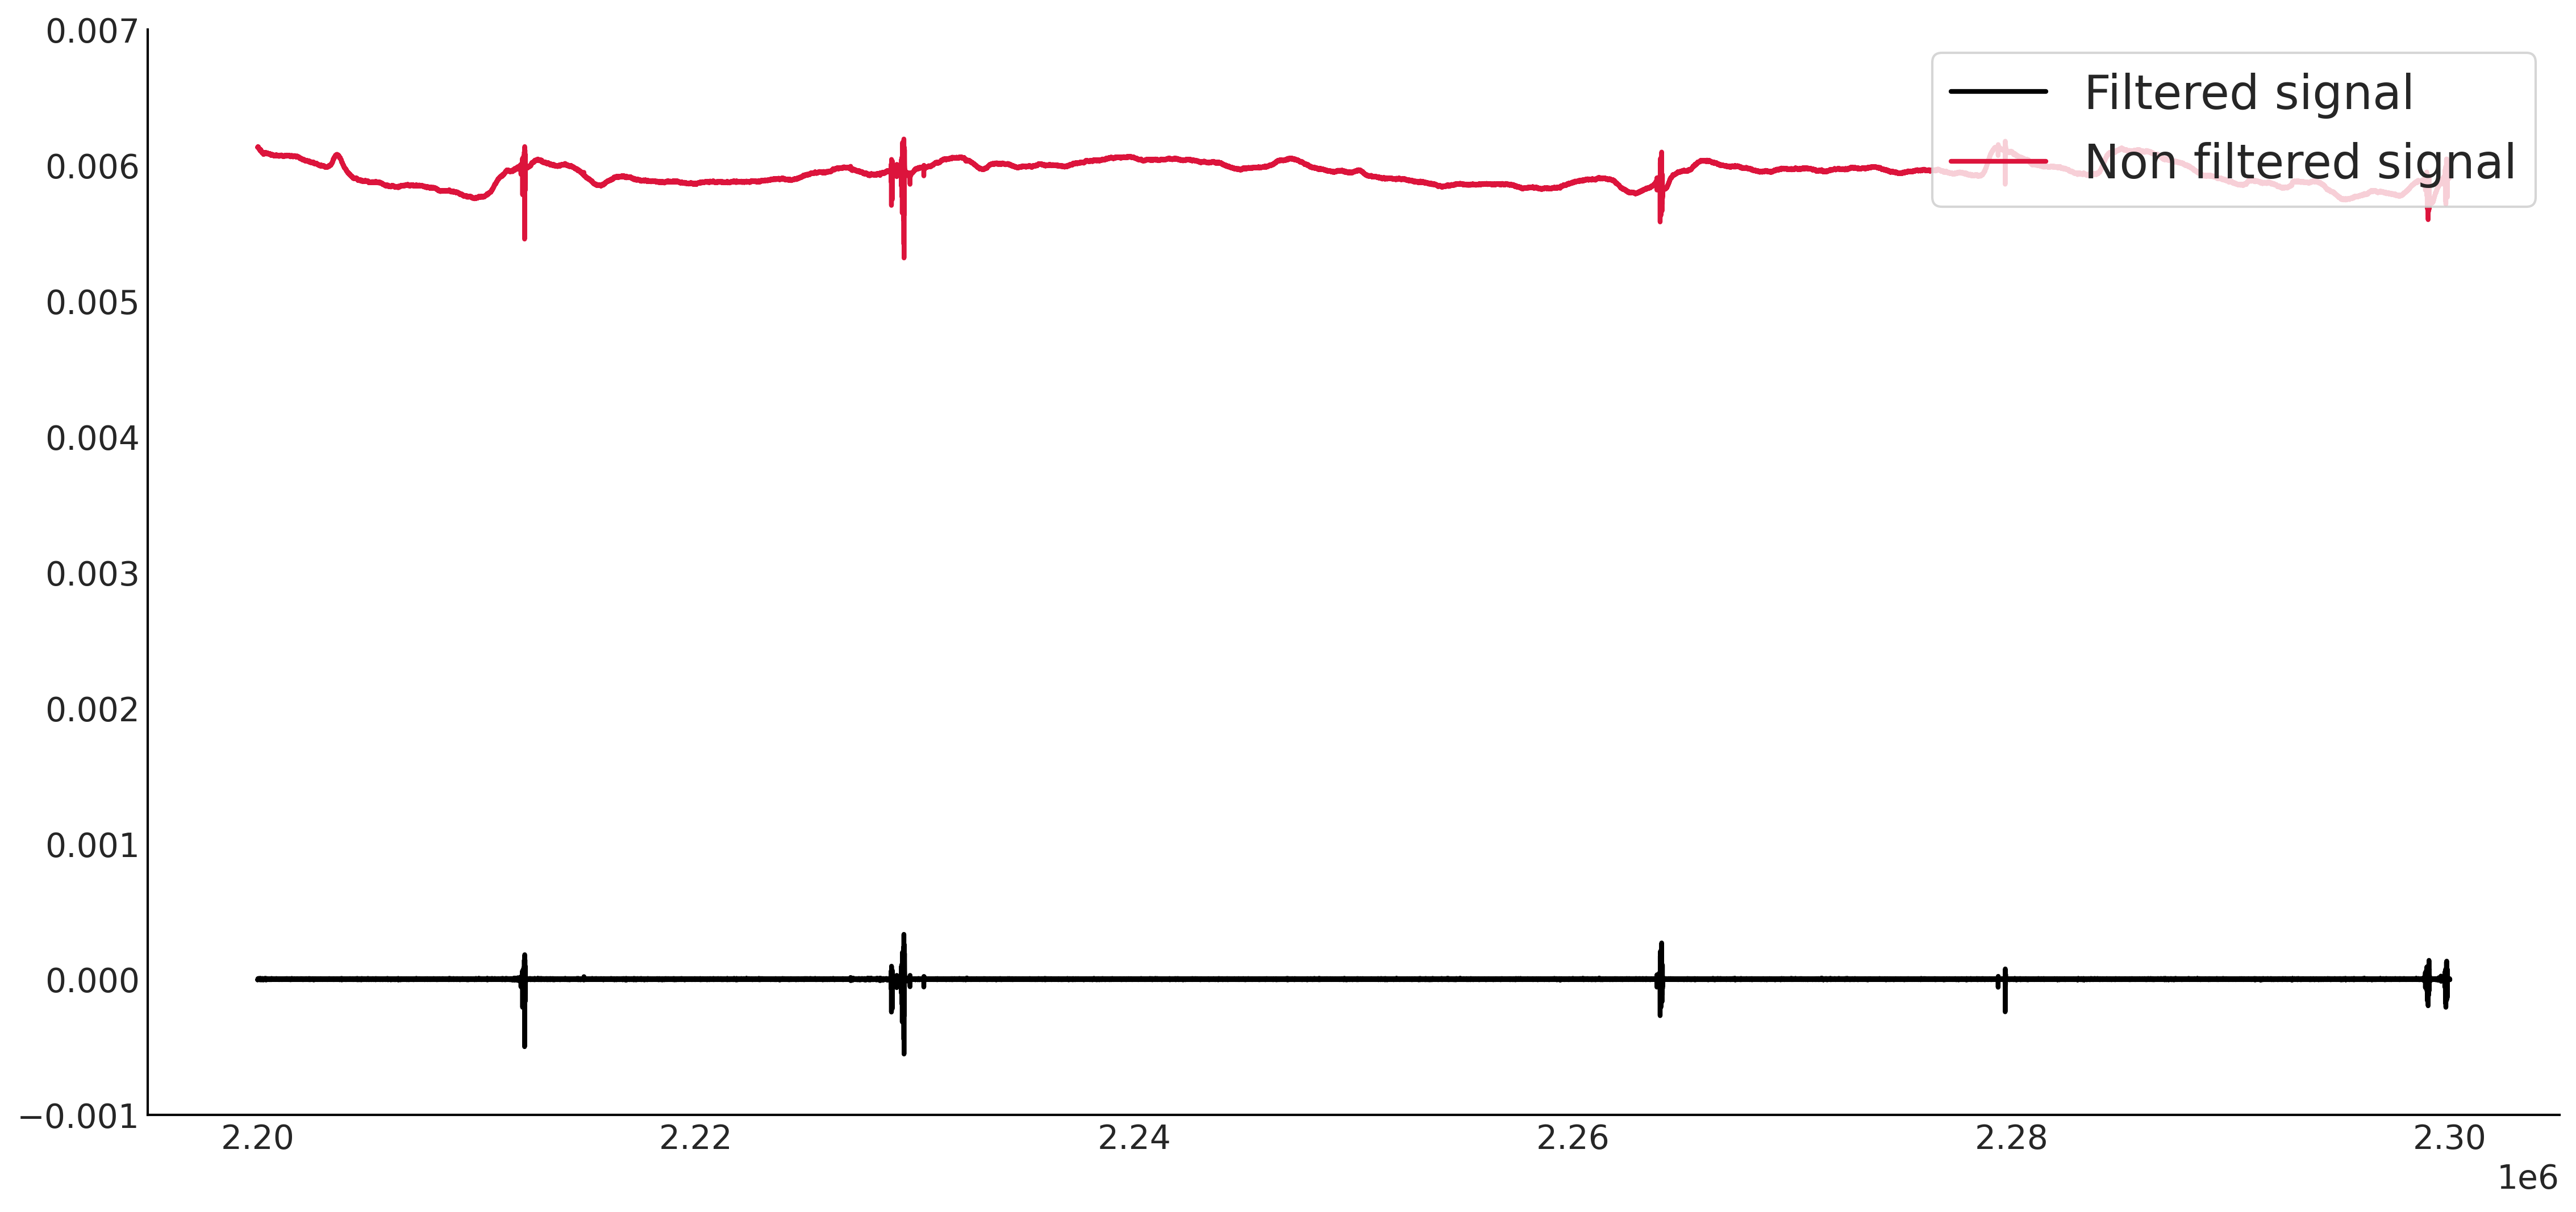

In [6]:
# Select EXG channels 1 2 3 4 with:
# - 1 for left hand down, 
# - 2 for left hand up,  
# - 3 and 4 for right hand down and up.

# This line of code ensures that we are only considering EMG channels)
raw_select_EMG = raw.copy().pick_channels(['EXG1','EXG2', 'EXG3', 'EXG4'], ordered = True)

# Bipolar derivation: EMGL = EXG1 - EXG2  and  EMGR = EXG3 - EXG4 
raw_bipolar = mne.set_bipolar_reference(raw_select_EMG, ['EXG1','EXG3'], ['EXG2','EXG4'], ch_name=['EMGL','EMGR'], copy=True)

# Apply a 10hz high-pass filter to data (i.e remove all frequencies below 10 Hz from the signal)
# raw_bipolar_filtered = useMne.applyFilter(raw_bipolar, ch_names = ['EMGL','EMGR'],low_cutoff = 10) # old method did not save metadata...
raw_bipolar_filtered = raw_bipolar.copy().filter(
    l_freq=10, 
    h_freq=None,
    method="iir", # method='fir' is default, you can adjust
    iir_params=dict(order=3, ftype="butter"))

# Get the EMG data
EMG_data = raw_bipolar_filtered.get_data(picks=['EMGL','EMGR']) # filtered
EMG_data_NF = raw_bipolar.get_data(picks=['EMGL','EMGR']) # not filtered




# ----- Plot EMG data section -----
# l = 2145000
# h = 2195000
l = 2200000
h = 2300000
x = np.arange(l,h)
plt.figure (1, figsize = (15, 7), dpi = 300)
# left plot
plt.plot(x,EMG_data[0, l:h], lw = 2, color = 'black', label="Filtered signal")
plt.plot(x,EMG_data_NF[0,l:h], lw = 2, color = 'crimson', label="Non filtered signal")
# right plot
# plt.plot(x,EMG_data[1, l:h], color = 'blue', alpha = .5)
# plt.plot(x,EMG_data_NF[1,l:h], color = 'orange', alpha = .2)
plt.legend(fontsize= 20, frameon=True, facecolor='white', loc = 'upper right')
plt.ylim(-0.001, 0.007)
plt.show()

### 1.3. Correct response-marker lag using behavioral RTs

**Goal**: for technical reasons, RTs collected in the behavioral datafile are more accurate than the response triggers in the EMG file.
For this reason, let's adjust the response triggers based on the behavioral datafile (you can ignore this section, as it is a bit technical). 

At the end, the diagnostic plot should show:
- **before correction:** visible lag between BDF RT and behavioral RT (around 1 frame = 16ms);
- **after correction:** points centered around zero.

In [7]:
# Load behavioral data ----
behavioral_data = np.load(os.path.join(current, 'data_example', 'behavior_EMG_data', nameSubj + '.npy'),allow_pickle=True)

RT = behavioral_data[:, 13].astype(float) * 1000  
assert RT.shape[0] == 240, "Not expected 240 trials recording..." 
RT[0:5]

array([1110.4659, 1011.3179, 1005.2827,  920.9571,  797.4834])

Following code calculates response times (RT) by subtracting the selected event of interest (start of RT) from the response time in a BDF file using corresponding trigger (here response triggers are 100, 101, 102, 103, 200, 201, 202, 203, and 250 for missed trial). It then compares them to behavioral RTs while counting valid and missed trials.

In [8]:
# Find RT in bdf file by computing time sample response - stimulus triggers
RT_bdf = []
RT_without_misses = []#select RT from the behavioral file (removing missed trials)
miss = 0

counter = 0 # to keep track of each trial
for i in range (len(raw_events)):#loop over triggers from the EMG file
     
    if raw_events[i,  2] == 250: # missed trial
        miss += 1
        counter += 1
        
    if raw_events[i,  2] in [100, 101, 102, 103]: # a response has been given by the subject 
        #convert the sample corresponding to each event  (stimulus and response) into time (in ms); 
        #to do that, we divide the sample by the sampling rate (1024) and multiply the result by 1000
        #we then compute time of the response - time of the stimulus to get the RT
        
        a = (raw_events[i, 0]/sf)*1000 - (raw_events[i-1, 0]/sf)*1000  # RT bdf file
        b = RT[counter] # RT behavior data
        RT_bdf.append(a)
        RT_without_misses.append(b)
        
        counter += 1
        
    if raw_events[i,  2] in [200,201,202,203]:# a premature response
        counter += 1

RT_bdf = np.array(RT_bdf) 
RT_without_misses = np.array(RT_without_misses)
lag_before = RT_bdf - RT_without_misses 
print("Trials number:", counter, '/ 240')
print("Trials missed:", miss)

Trials number: 240 / 240
Trials missed: 0


Next, the following cell corrects the response markers in the BDF file to align them with the behavioral data. It then recalculates the corrected RTs and measures the remaining difference from the behavioral RTs.

In [9]:
# Convert RT from the behavioral file into samples
RT_converted = np.round(1024*RT/1000)
# Make a deep copy of the event file
corrected_events = copy.deepcopy(raw_events[:,(0,2)])

# --- compute corrected RTs and compare with behavioral datafile
counter = 0
for i in range (len(corrected_events)):
    if corrected_events[i, 1] == 250:
        counter = counter + 1 #don't modify the "missed trial" marker
    elif corrected_events[i, 1] in [100,101,102,103]: 
        corrected_events[i, 0] = corrected_events[i-1, 0] + RT_converted[counter] # adjust the timing of response markers to match the behavioral datafile
        counter = counter + 1
    elif corrected_events[i, 1] in  [200,201,202,203]:
        counter = counter + 1

if counter == 240: #because there are 240 trials
    print ("Correction of response markers completed.")
else: raise ValueError("PROBLEM with the correction of response markers.")


RT_bdf_corrected = []
for i in range (len(corrected_events)):
    if corrected_events[i, 1] in [100, 101, 102, 103]: 
        RT_bdf_corrected.append((corrected_events[i, 0]/1024)*1000 - (corrected_events[i-1, 0]/1024)*1000)
RT_bdf_corrected = np.array(RT_bdf_corrected)    
lag_after = np.array(RT_without_misses - RT_bdf_corrected)     

Correction of response markers completed.


Finally, we plot two graphs comparing the time lags between behavioral RTs and those of the BDF, before and after correction. The first shows the initial differences (should be around one frame = 15-20ms), the second the residuals after alignment (around 0).

Text(0, 0.5, 'RT lag (ms)')

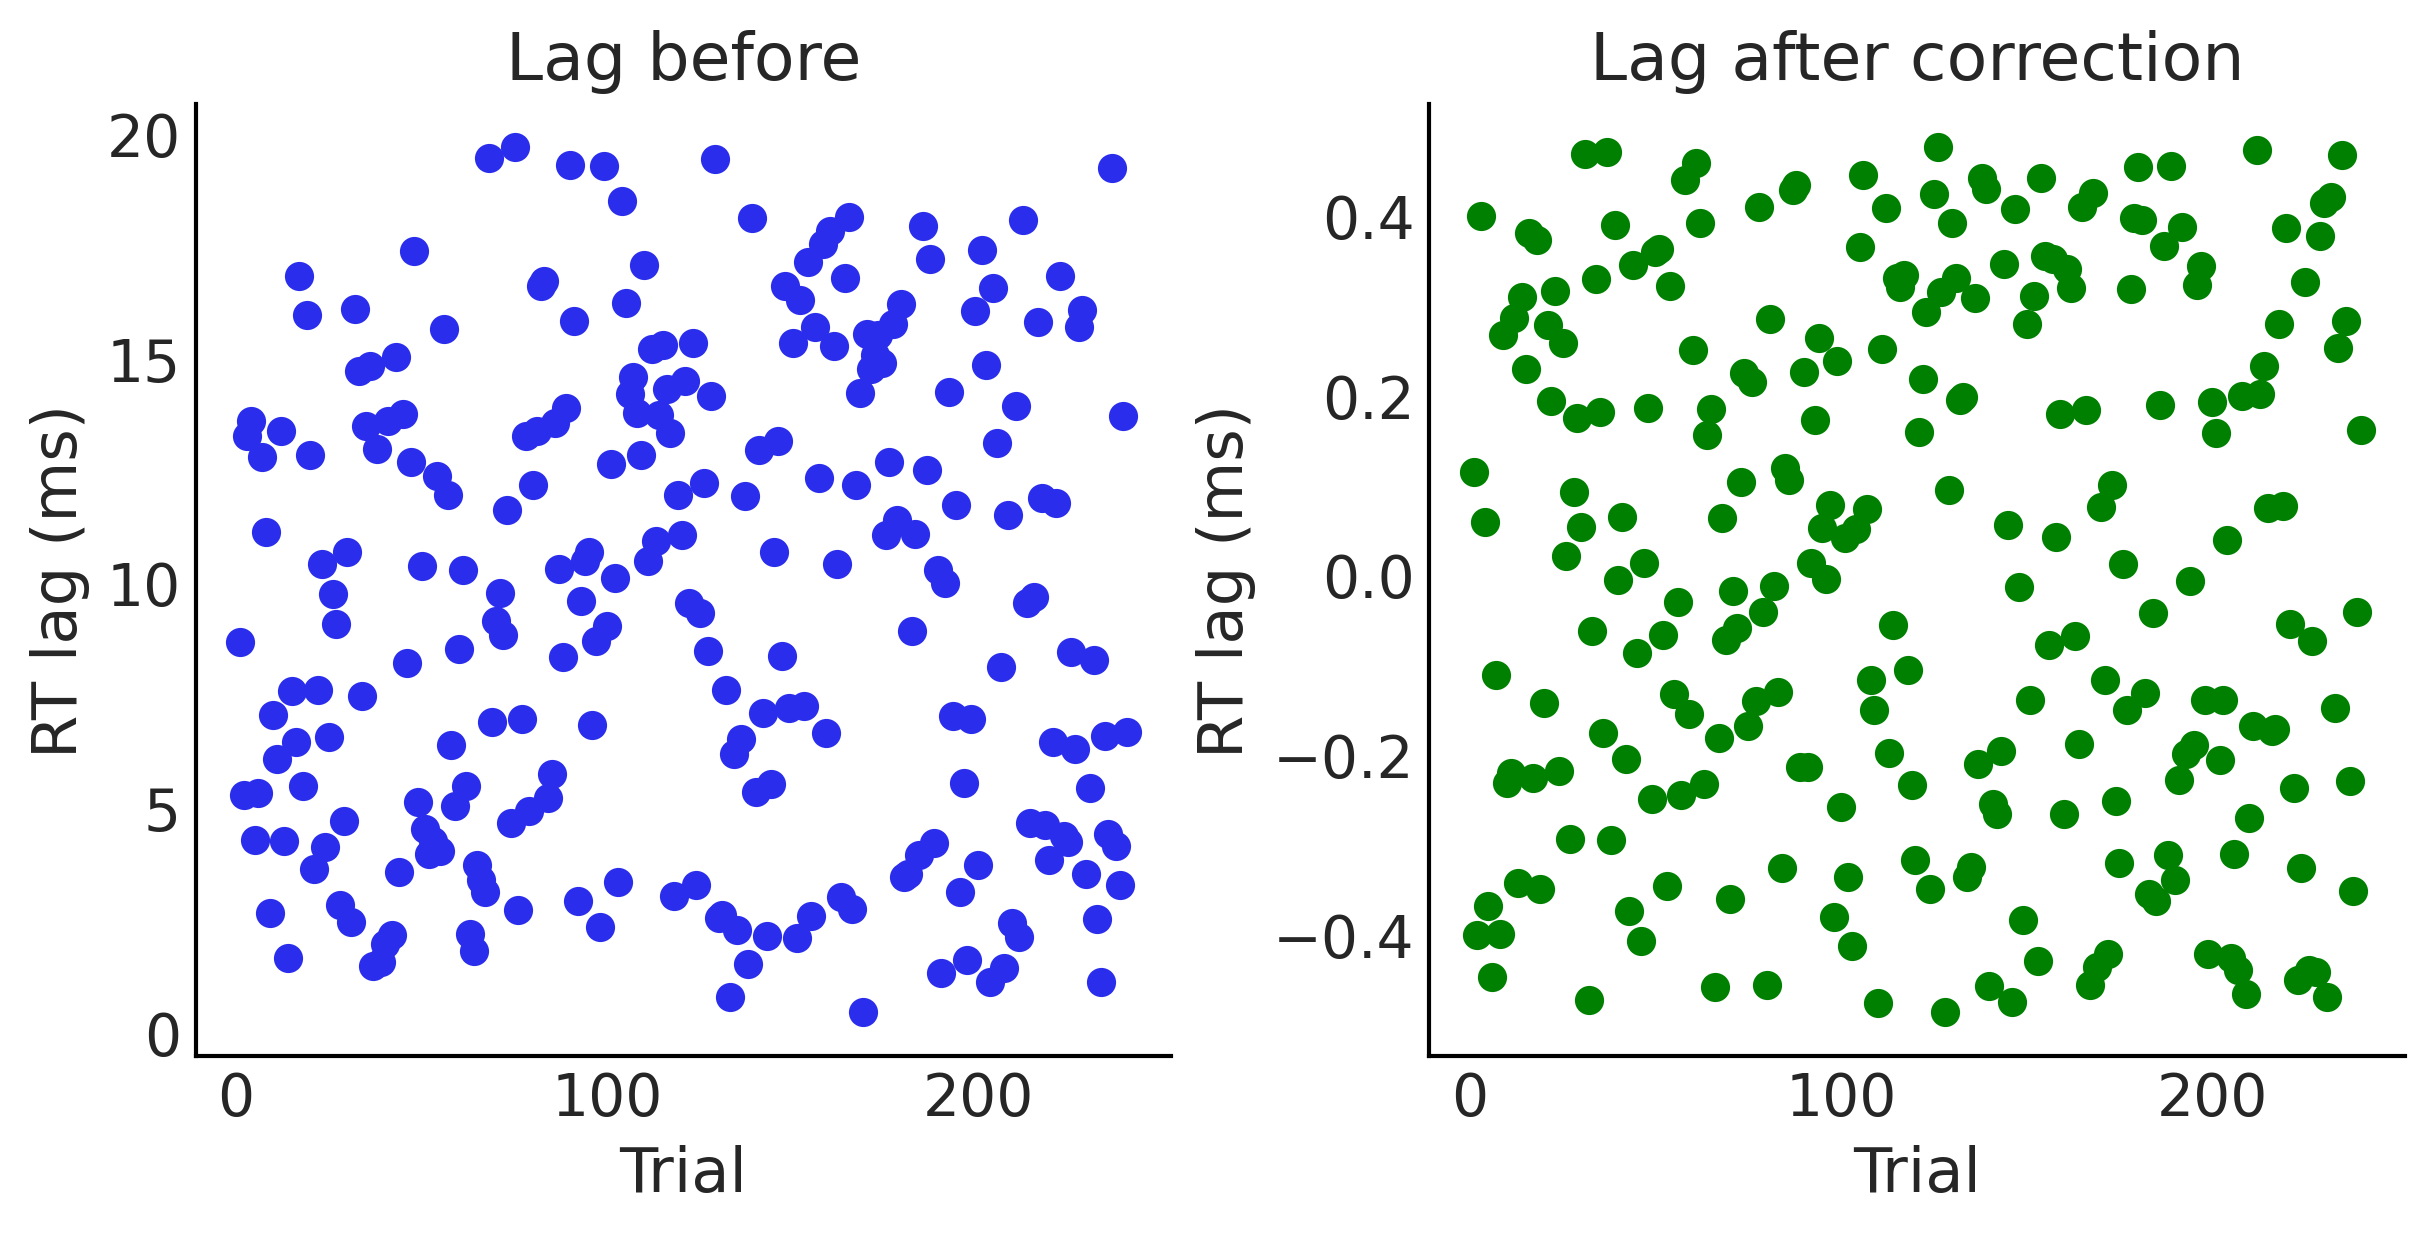

In [10]:
# --- Plot before lag event ---
fig, axs = plt.subplots(1, 2, figsize=(8,4), dpi=300)

x = np.arange(1, len(lag_before) + 1)
y = lag_before

plt.subplot(1, 2, 1)
plt.plot(x, y, marker="o", linestyle="")
plt.title("Lag before")
plt.xlabel("Trial")
plt.ylabel("RT lag (ms)")


# --- Plot after lag event ---
x = np.arange(1, len(lag_after) +1)
y = lag_after

plt.subplot(1, 2, 2)
plt.plot(x, y, marker="o", linestyle="", color = "green")
plt.title("Lag after correction")
plt.xlabel("Trial")
plt.ylabel("RT lag (ms)")

Save your EMG and RT corrected triggers data:

In [11]:
save_fif = False

if save_fif:
    corrected_events_to_save = np.insert(corrected_events, 1, raw_events[:, 1], axis=1)

    os.chdir(os.path.join(current, "data_example", "EMG_processing", "processed_data_STEP1", "triggers"))
    np.save(f"{nameSubj}_corrected_triggers.npy", corrected_events_to_save)

    os.chdir(os.path.join(current, "data_example", "EMG_processing", "processed_data_STEP1", "EMG_signals"))
    raw_bipolar_filtered.save(f"{nameSubj}_EMGstep1.fif", overwrite=True)
    raw_bipolar.save(f"{nameSubj}_EMGstep1_NF.fif", overwrite=True)

    print(">> Corrected triggers and FIF files saved.")
else:
    print(">> Not saved.")

>> Not saved.


## 2. EMG Onset/Offset automatic detection
It is important to remember that although many methods have been proposed to determine the start and end of EMG peaks, none has proven as effective as human visual detection. The detection presented here is based on the MyOnset/EMG toolbox (https://github.com/lspieser/myonset); more specifically, the procedure described in Achard et al. (2025, JEP: General) appendix A and B for onset detection over large epochs (https://dx.doi.org/10.1037/xge0001748). You can also see Servant et al. (2021, JEP: General) and Dendauw et al. (2024, Psych Rev).

In [12]:
# Load EMG signal data (previously saved)
os.chdir(os.path.join(current, "data_example", "EMG_processing", "processed_data_STEP1", "triggers"))
triggers = np.load(nameSubj + "_corrected_triggers.npy")

os.chdir(os.path.join(current, "data_example", "EMG_processing", "processed_data_STEP1", "EMG_signals"))
EMGdata = mne.io.read_raw_fif(nameSubj + "_EMGstep1.fif", preload=True, verbose=False)
EMGdataNF = mne.io.read_raw_fif(nameSubj + "_EMGstep1_NF.fif", preload=True, verbose=False)

sf = EMGdata.info["sfreq"]

# Get the EMG data
EMG_data = EMGdata.get_data(picks=["EMGL", "EMGR"])
EMG_data_NF = EMGdataNF.get_data(picks=["EMGL", "EMGR"])

### 2.1. Organize event (tmin, tmax, epoch, triggers, etc.)
Next, we prepare data:
- Organizes events from triggers (samples, codes, channels) into an Events structure.
- Segments the EMG data into epochs centered on the stimulus onset (window, e.g.,: -0.3s to 13s).
- Extracts the epochs and generates a time vector to synchronize the data with the stimulus.

In [13]:
#-------------------------------------------------------
# ----- Organise events before EMG onset detection -----
#-------------------------------------------------------
events = Events(sample = triggers[:,0], code = triggers[:,2], chan = [-1]*triggers[:,0].shape[0], sf=sf)
print ("> Events sucessfully organized")


#-------------------------------------------------------
# ----- Segment data into epochs time-locked on stimulus onset (so the 0 of time corresponds to stimulus onset)
#-------------------------------------------------------
# Interval used for segmentation, in seconds
tmin = -0.3 
tmax = 13 #which corresponds to 2.5s of response window 

# Extract EMG data
EMG_data_extracted = EMG_data

#  Trigg stim id
trigg_stim_id = np.array( [11,12,13,  14,15,16] ) # possible stimulus triggers 
trigg_resp_id = {'left_correct': 101, 'left_incorrect': 100, 'right_correct' : 103, 'right_incorrect':102, 'left_correct_early': 201, 'left_incorrect_early': 200, 'right_correct_early' : 203, 'right_incorrect_early':202, 'no_resp':250}
trigg_emg_id = {'onset': 350 , 'offset': 351 }

# Determine events corresponding to stimulus onset
epEvts = events.segment(codeT0=list(trigg_stim_id), tmin=tmin, tmax=tmax)

# Extract data epochs based on these events (stimulus onset)
dataEpochs = evt.getDataEpochs(EMG_data_extracted, epEvts)  # shape (n_epochs, n_channels, n_times)

# Extract time vector for the epoch (with a 1024 Hz sampling rate)
epochTime = evt.times(tmin, tmax, sf) # np vector array containing real time values for the epoch

print ("> Epochs sucessfully organized")

> Events sucessfully organized
Found 240 epoch(s).
> Epochs sucessfully organized


You can plot EMG signal as follows:

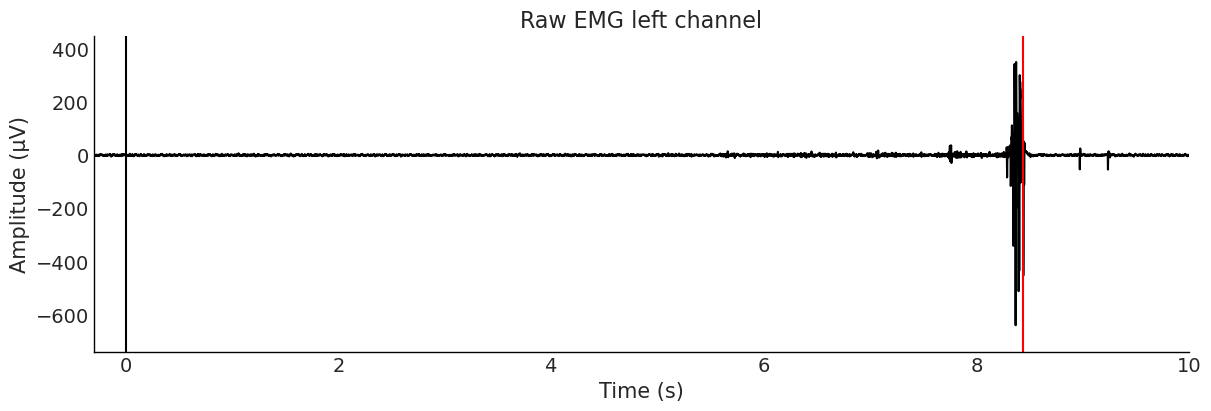

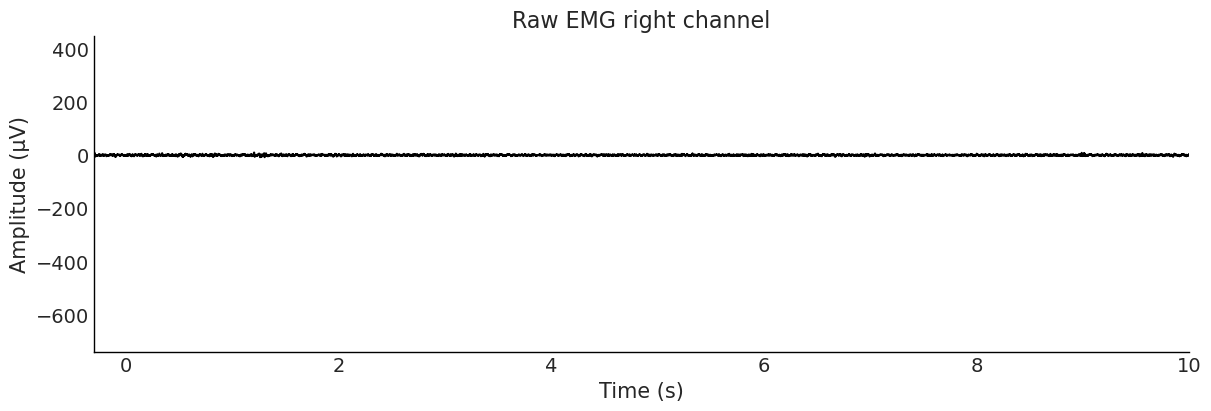

In [ ]:
trial = 218
sig_raw = dataEpochs[trial, :, :] * 1e6  # Convert to microvolts


# Find response latency ------------
stim_list = epEvts.listEvtsTrials[trial].findEvents(code=list(trigg_stim_id))

response_codes = [100, 101, 102, 103, 200, 201, 202, 203]
resp_list = epEvts.listEvtsTrials[trial].findEvents(code=response_codes)
resp_after_stim = resp_list[resp_list > stim_list[0]]

if len(resp_after_stim) > 0:
    resp_idx = resp_after_stim[0]
    resp_latency = epEvts.listEvtsTrials[trial].Latency.sample[resp_idx]
    resp_code = epEvts.listEvtsTrials[trial].code[resp_idx]
    chan_resp_left = resp_code in [100, 101, 200, 201]
else:
    resp_latency = len(epochTime) - 1
    resp_code = 250
    chan_resp_left = None

rt_time = epochTime[int(resp_latency)]


# Find min and max amplitude signal --------
global_min = min(sig_raw[0, :].min(), sig_raw[1, :].min())
global_max = max(sig_raw[0, :].max(), sig_raw[1, :].max())
margin = 0.1 * (global_max - global_min)
global_min -= margin
global_max += margin


# ----------------- Plot -----------------
chan = 0  # 0 for EMGL, 1 for EMGR
signal_plot = sig_raw[chan, :]
time = epochTime

plt.figure(figsize=(12,4))
plt.plot(epochTime, signal_plot, color = 'black')
plt.title("Raw EMG left channel")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.ylim([global_min, global_max])
plt.xlim([-0.3, 10])
# plt.xlim([8.5, 9.1])
plt.axvline(0, color='k', linestyle='-', label='Stimulus onset')
if chan_resp_left is True: plt.axvline(rt_time, color='red', linestyle='-', label='RT')
plt.show()

chan = 1
signal_plot = sig_raw[chan, :]
plt.figure(figsize=(12,4))
plt.plot(epochTime, signal_plot, color = 'black')
plt.title("Raw EMG right channel")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.ylim([global_min, global_max])
plt.xlim([-0.3, 10])
if chan_resp_left is False: plt.axvline(rt_time, color='red', linestyle='-', label='RT')
plt.show()

### 2.2. Rectified EMG signal
Now, we rectify the EMG signal (absolute value), then smoothes the envelope via a moving average (10 ms window). It finally displays the 3 versions of the signal (raw, rectified, smoothed) for the selected-response EMG channel.

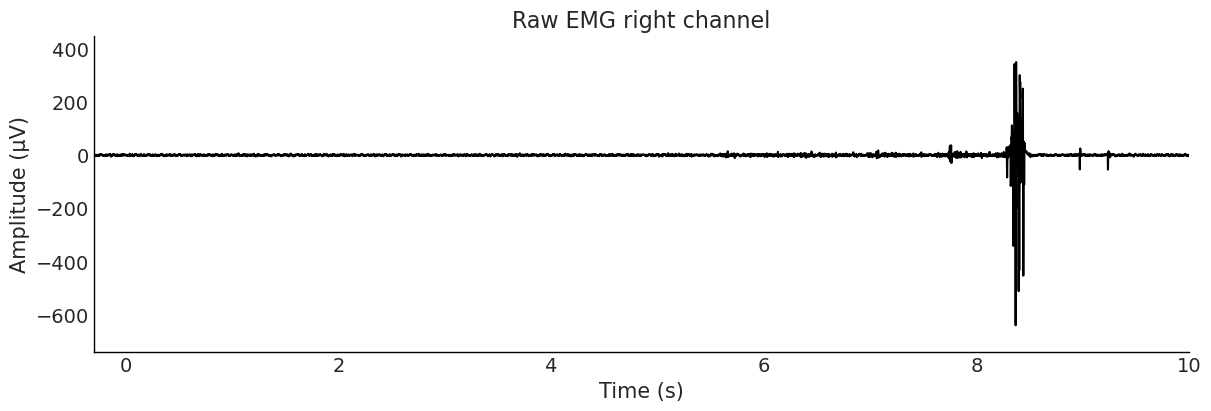

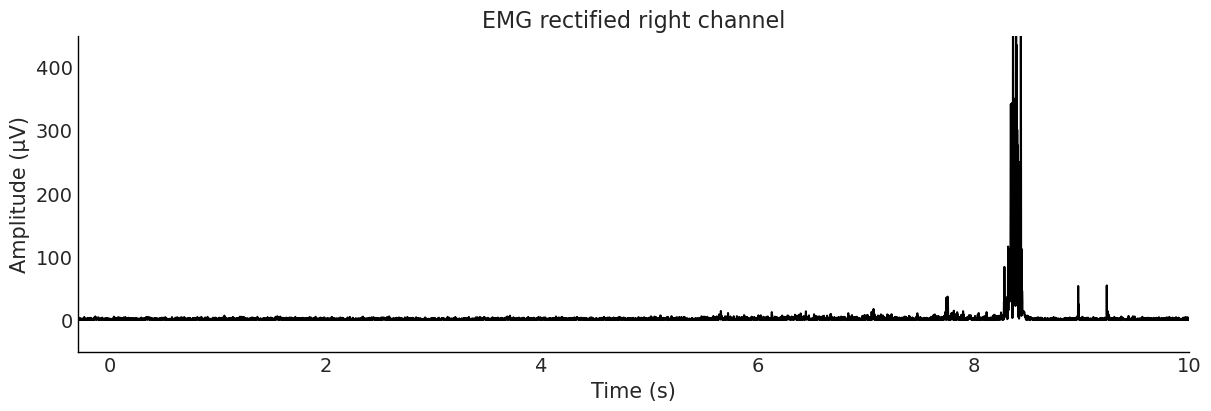

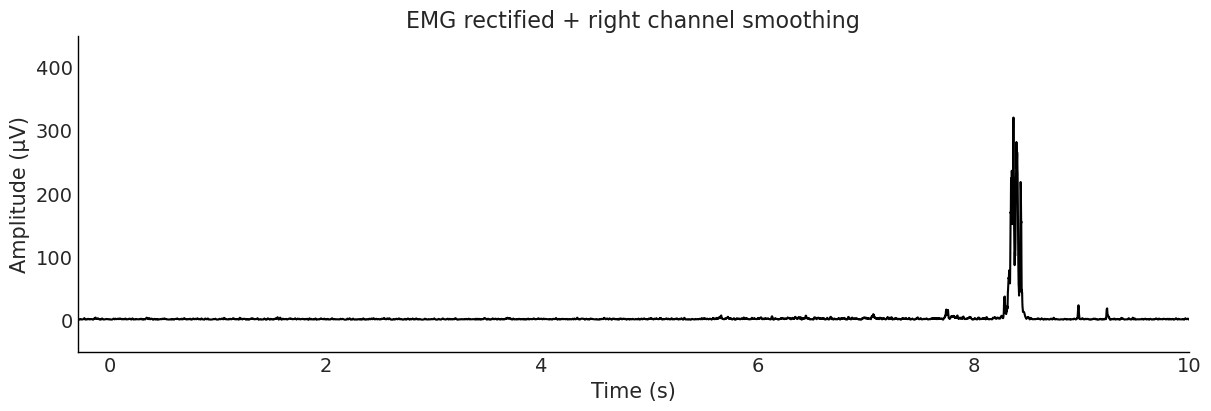

In [15]:
# Rectification
sig_rect = np.abs(sig_raw)

# Enveloppe via moyenne mobile 10 ms
sf = epEvts.sf
win_ms = 10
win_samples = max(1, int(win_ms * 1e-3 * sf))
kernel = np.ones(win_samples) / win_samples

env = np.vstack([
    np.convolve(sig_rect[ch], kernel, mode='same')
    for ch in range(2)
])



# --- Plots signal Raw vs rectified ---
if chan_resp_left: chan = 0 
else: chan = 1  

signal_plot = sig_raw[chan, :]
plt.figure(figsize=(12,4))
plt.plot(epochTime, signal_plot, color = 'black')
plt.title("Raw EMG right channel")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.ylim([global_min, global_max])
plt.xlim([-0.3, 10])
plt.show()

signal_plot = sig_rect[chan, :]
plt.figure(figsize=(12,4))
plt.plot(epochTime, signal_plot, color = 'black')
plt.title("EMG rectified right channel")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.ylim([-50, global_max])
plt.xlim([-0.3, 10])
plt.show()


signal_plot = env[chan, :]
plt.figure(figsize=(12,4))
plt.plot(epochTime, signal_plot, color = 'black')
plt.title("EMG rectified + right channel smoothing")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.ylim([-50, global_max])
plt.xlim([-0.3, 10])
plt.show()

### 2.3. Onset/offset automatic detection
The following code simulates algorithm detection with a final plot, as follows:
- Find segments where the rectified EMG signal exceeds the threshold
- Merge windows separated too closely (< 25ms)
- Remove windows that are too short (minimum duration = n + 3 samples)
- Remove windows before t=0 or after the response

In [16]:
# Functions --------------------------------------
def get_windows_above_threshold(envelope, thr):
    above = envelope > thr
    diff = np.diff(above.astype(int))

    starts = np.where(diff == 1)[0] + 1
    ends = np.where(diff == -1)[0] + 1

    if above[0]:
        starts = np.insert(starts, 0, 0)
    if above[-1]:
        ends = np.append(ends, len(above))
    return np.array(list(zip(starts, ends)), dtype=int)

def merge_windows(wins, tol_s, sf):
    if len(wins) == 0:
        return wins
    tol = int(round(tol_s * sf))
    merged = []
    cur_s, cur_e = wins[0]

    for s, e in wins[1:]:
        if s - cur_e <= tol:
            cur_e = e
        else:
            merged.append((cur_s, cur_e))
            cur_s, cur_e = s, e
    merged.append((cur_s, cur_e))
    return np.array(merged, dtype=int)

def prune_short_windows(wins, sf, epoch_len):
    small = sum((e - s) < 7 for s,e in wins)
    n = small / (epoch_len / sf)
    min_len = int(np.ceil(n + 3))
    kept = np.array([(s,e) for (s,e) in wins if (e - s) >= min_len], dtype=int)
    return kept, min_len


def crop_windows(wins, t0, tResp):
    cropped = [
        (max(s, t0), e)
        for s, e in wins
        if e > t0 and s < tResp
    ]

    if len(cropped) == 0:
        return np.empty((0, 2), dtype=int)

    return np.array(cropped, dtype=int)






# --------------------------- Perform example detection ----------------------------
idx_t0 = emg.findTimes(0., epochTime)
baseline_idx = np.arange(0, idx_t0)

signal = sig_rect
# Mean and SD baseline per EMG channel
Mb = np.mean(signal[:, baseline_idx], axis=1)
SDb = np.std(signal[:, baseline_idx], axis=1)
criterion = Mb + 7 * SDb # remember that we chosen criterion = Mb + 7 * SDb

# Get active window contain EMG signal active based on threshold criterion
wins_raw = {ch: get_windows_above_threshold(signal[ch], criterion[ch]) for ch in [0,1]}

# Merge to EMG active windonw if less than 25ms space
wins_merged = {ch: merge_windows(wins_raw[ch], 0.025, sf) for ch in [0,1]}

# Delete to short windows
epoch_len_samples = signal.shape[1]
wins_pruned = {}
min_lengths = {}
for ch in [0,1]:
    wins_pruned[ch], min_lengths[ch] = prune_short_windows(wins_merged[ch], sf, epoch_len_samples)

# Crop window if after response
wins_final = {ch: crop_windows(wins_pruned[ch], idx_t0, resp_latency) for ch in [0,1]}

# Visual inspection
to_remove = [0, 2]
to_remove = [idx for idx in to_remove if idx < len(wins_final[0])]

win_visual = {
    0: np.delete(wins_final[0], to_remove, axis=0),
    1: wins_final[1].copy()
}

We compute integrate profil on all window found previously:

In [17]:
def moving_average_emgtools(x, win_samples):
    if win_samples <= 1:
        return x
    x = np.insert(x, 0, np.ones(int(win_samples - int(win_samples)//2)) * x[0])
    x = np.append(x, np.ones(int(win_samples)//2) * x[-1])
    cs = np.cumsum(x)
    return (cs[win_samples:] - cs[:-win_samples]) / float(win_samples)


def integrated_profile_emgtools(data_trial, times):
    cs = np.abs(data_trial).cumsum()
    a = cs[-1] / (times[-1] - times[0])
    straight_line = a * times
    return cs - straight_line


def signal_windows_emgtools(sections, start, end):
    sections = np.asarray(sections, dtype=int)

    if np.any(sections < start):
        start = 0
    if np.any(sections > end):
        end = np.max(sections)

    borders = np.transpose((
        np.hstack((start, sections[:-1, 1])),
        np.hstack((sections[1:, 0], end))
    ))

    windows = np.mean((sections, borders), axis=0)
    return np.asarray(windows, dtype=int)


def integrated_profile_on_window_emgtools_style(
    data_trial,
    times,
    windows,
    window_i,
    sf,
    ip_search=(-0.050, 0.050),
    movingAvg_window=0.015
):
    """
    Reproduit emgTools.getOnsets
    à partir de fenêtres actives déjà détectées.

    data_trial : 1D array
        Signal EMG filtré. Il peut être signé, car l'IP prend np.abs(data_trial).
    times : 1D array
        Axe temporel de l'epoch.
    windows : array, shape n_windows x 2
        Fenêtres actives déjà détectées, par exemple wins_final[chan].
    window_i : int
        Indice de la fenêtre active à traiter.
    sf : float
        Fréquence d'échantillonnage.
    """

    windows = np.asarray(windows, dtype=int)

    if len(windows) == 0:
        raise ValueError("No EMG active window found.")

    # Equivalent du t0 de emgTools
    t0 = np.abs(times - 0).argmin()

    # Étape signalWindows de emgTools
    ip_windows = signal_windows_emgtools(windows, t0, len(data_trial))

    # Baseline initiale + baseline finale
    bsl_idx = np.hstack((
        np.arange(0, ip_windows[0, 0]),
        np.arange(ip_windows[-1, 1], len(data_trial))
    ))

    b = window_i
    active_idx = np.arange(ip_windows[b, 0], ip_windows[b, 1])

    # Signal reconstruit : baseline + fenêtre active
    section_idx = np.hstack((bsl_idx, active_idx))
    section_idx.sort()

    shift = ip_windows[b, 0] - ip_windows[0, 0]

    # Fenêtre de recherche autour de la fenêtre détectée par seuil
    sample_search_start = int(windows[b, 0] + np.floor(ip_search[0] * sf) - shift)
    sample_search_end = int(windows[b, 1] + np.ceil(ip_search[1] * sf) - shift)

    lower_bound = ip_windows[b, 0] - shift
    upper_bound = ip_windows[b, 1] - shift

    sample_search = np.arange(
        max(sample_search_start, lower_bound),
        min(sample_search_end, upper_bound)
    )

    if len(sample_search) < 3:
        raise ValueError("sample_search too short for integrated profile.")

    # Integrated profile sur le signal reconstruit
    data_section = data_trial[section_idx]
    times_section = times[:len(section_idx)]

    ip_all = integrated_profile_emgtools(data_section, times_section)

    movingAvg_size = int(round(movingAvg_window * sf))
    ip_search_smooth = moving_average_emgtools(ip_all[sample_search], movingAvg_size)

    # Même logique que getOnsetIntegratedProfile
    on_rel = int(np.argmin(ip_search_smooth))
    off_rel = on_rel + int(np.argmax(ip_search_smooth[on_rel:]))

    on_ip = sample_search[0] + on_rel
    off_ip = sample_search[0] + off_rel

    # Retour dans les indices originaux de l'epoch
    on_ip_epoch = on_ip + shift
    off_ip_epoch = off_ip + shift

    # Même choix que getOnsets : earliest between IP and threshold window
    onset_final = int(np.min((windows[b, 0], on_ip_epoch)))
    offset_final = int(np.min((windows[b, 1], off_ip_epoch)))

    # Pour plotter l'IP sur les indices originaux
    ip_plot_idx = section_idx[sample_search]
    ip_plot = ip_search_smooth

    return {
        "window": tuple(windows[b]),
        "ip_window": tuple(ip_windows[b]),
        "section_idx": section_idx,
        "sample_search": sample_search,
        "ip_plot_idx": ip_plot_idx,
        "ip_plot": ip_plot,
        "on_ip_epoch": int(on_ip_epoch),
        "off_ip_epoch": int(off_ip_epoch),
        "onset_idx": onset_final,
        "offset_idx": offset_final
    }

### 2.4. Visual illustration of EMG segmentation
Now, we plot all steps from EMG rectified signal to final result of detection for one channel:

In [18]:
# -------------------------------------------------------------------------
# Function to draw IP plots directly into existing axes
# -------------------------------------------------------------------------

def plot_ip_on_axes(ip_axes, wins_final=wins_final, show_indices=False):
    chan = 0 if chan_resp_left else 1
    n_windows = len(wins_final[chan])

    window_indices = [0, 1, 2, 3]
    window_indices = [w if w >= 0 else n_windows + w for w in window_indices]
    window_indices = [w for w in window_indices if 0 <= w < n_windows]

    if show_indices:
        print(f"Number of detected windows: {n_windows}")
        print(f"Selected windows: {window_indices}")

    ip_results = []

    for w_i in window_indices:
        res = integrated_profile_on_window_emgtools_style(
            data_trial=sig_raw[chan, :],
            times=epochTime,
            windows=wins_final[chan],
            window_i=w_i,
            sf=sf,
            ip_search=(-0.0250, 0.0250),
            movingAvg_window=0.015
        )
        ip_results.append(res)

    ymin_max = [[-45, 50], [-45, 50], [-45, 50], [-650, 500]]

    for j, ax in enumerate(ip_axes):
        if j >= len(ip_results):
            ax.axis("off")
            continue

        res = ip_results[j]
        selected_window_i = window_indices[j]

        start, end = res["window"]
        onset_idx = res["onset_idx"]
        offset_idx = res["offset_idx"]
        ip_idx, ip = res["ip_plot_idx"], res["ip_plot"]

        if show_indices:
            print(f"Window {selected_window_i}: {epochTime[start]:.3f}–{epochTime[end-1]:.3f} s")

        ymin, ymax = ymin_max[j]

        ip_to_plot = ip.copy()

        if np.ptp(ip_to_plot) > 0:
            ip_scaled = (ip_to_plot - np.min(ip_to_plot)) / np.ptp(ip_to_plot)
            ip_scaled = (ip_scaled - 0.5) * 0.70 * (ymax - ymin)
        else:
            ip_scaled = np.zeros_like(ip_to_plot)

        ax.plot(epochTime, sig_raw[chan, :], color="black", alpha=0.20, linewidth=1, label="Raw EMG signal" if j == 0 else None)
        ax.plot(epochTime[ip_idx], sig_raw[chan, ip_idx], color="black", alpha=0.65, linewidth=1, label="IP search window" if j == 0 else None)


        # # Cross
        # ax.plot(epochTime[onset_idx], 0, marker="X", color="#1846ff", markersize=5, markeredgewidth=2, linestyle="None", label="Onset" if j == 0 else None)
        # ax.plot(epochTime[offset_idx], 0, marker="X", color="turquoise", markersize=5, markeredgewidth=2, linestyle="None", label="Offset" if j == 0 else None)
        # Onset / offset vertical lines
        
        # Lines
        ax.axvline(epochTime[onset_idx], color="#1846ff", linestyle="-", linewidth=0.75, alpha=0.9, label="Onset" if j == 0 else None)
        ax.axvline(epochTime[offset_idx], color="turquoise", linestyle="-", linewidth=0.75, alpha=0.9, label="Offset" if j == 0 else None)
        
        # IP        
        ax.plot(epochTime[ip_idx], ip_scaled, color="white", linewidth=3)
        ax.plot(epochTime[ip_idx], ip_scaled, color="purple", linewidth=1, label="Integrated profile" if j == 0 else None)

        ax.set_ylim([ymin, ymax])
        if j != 0: ax.set_xlim([epochTime[ip_idx[0]] - 0.15, epochTime[ip_idx[-1]] + 0.15])
        else: ax.set_xlim([epochTime[ip_idx[0]] - 0.9, epochTime[ip_idx[-1]] + 0.15])
        ax.tick_params(axis="y", labelsize=8)
        ax.tick_params(axis="x", labelsize=8)

    handles, labels = ip_axes[0].get_legend_handles_labels()

    return handles, labels

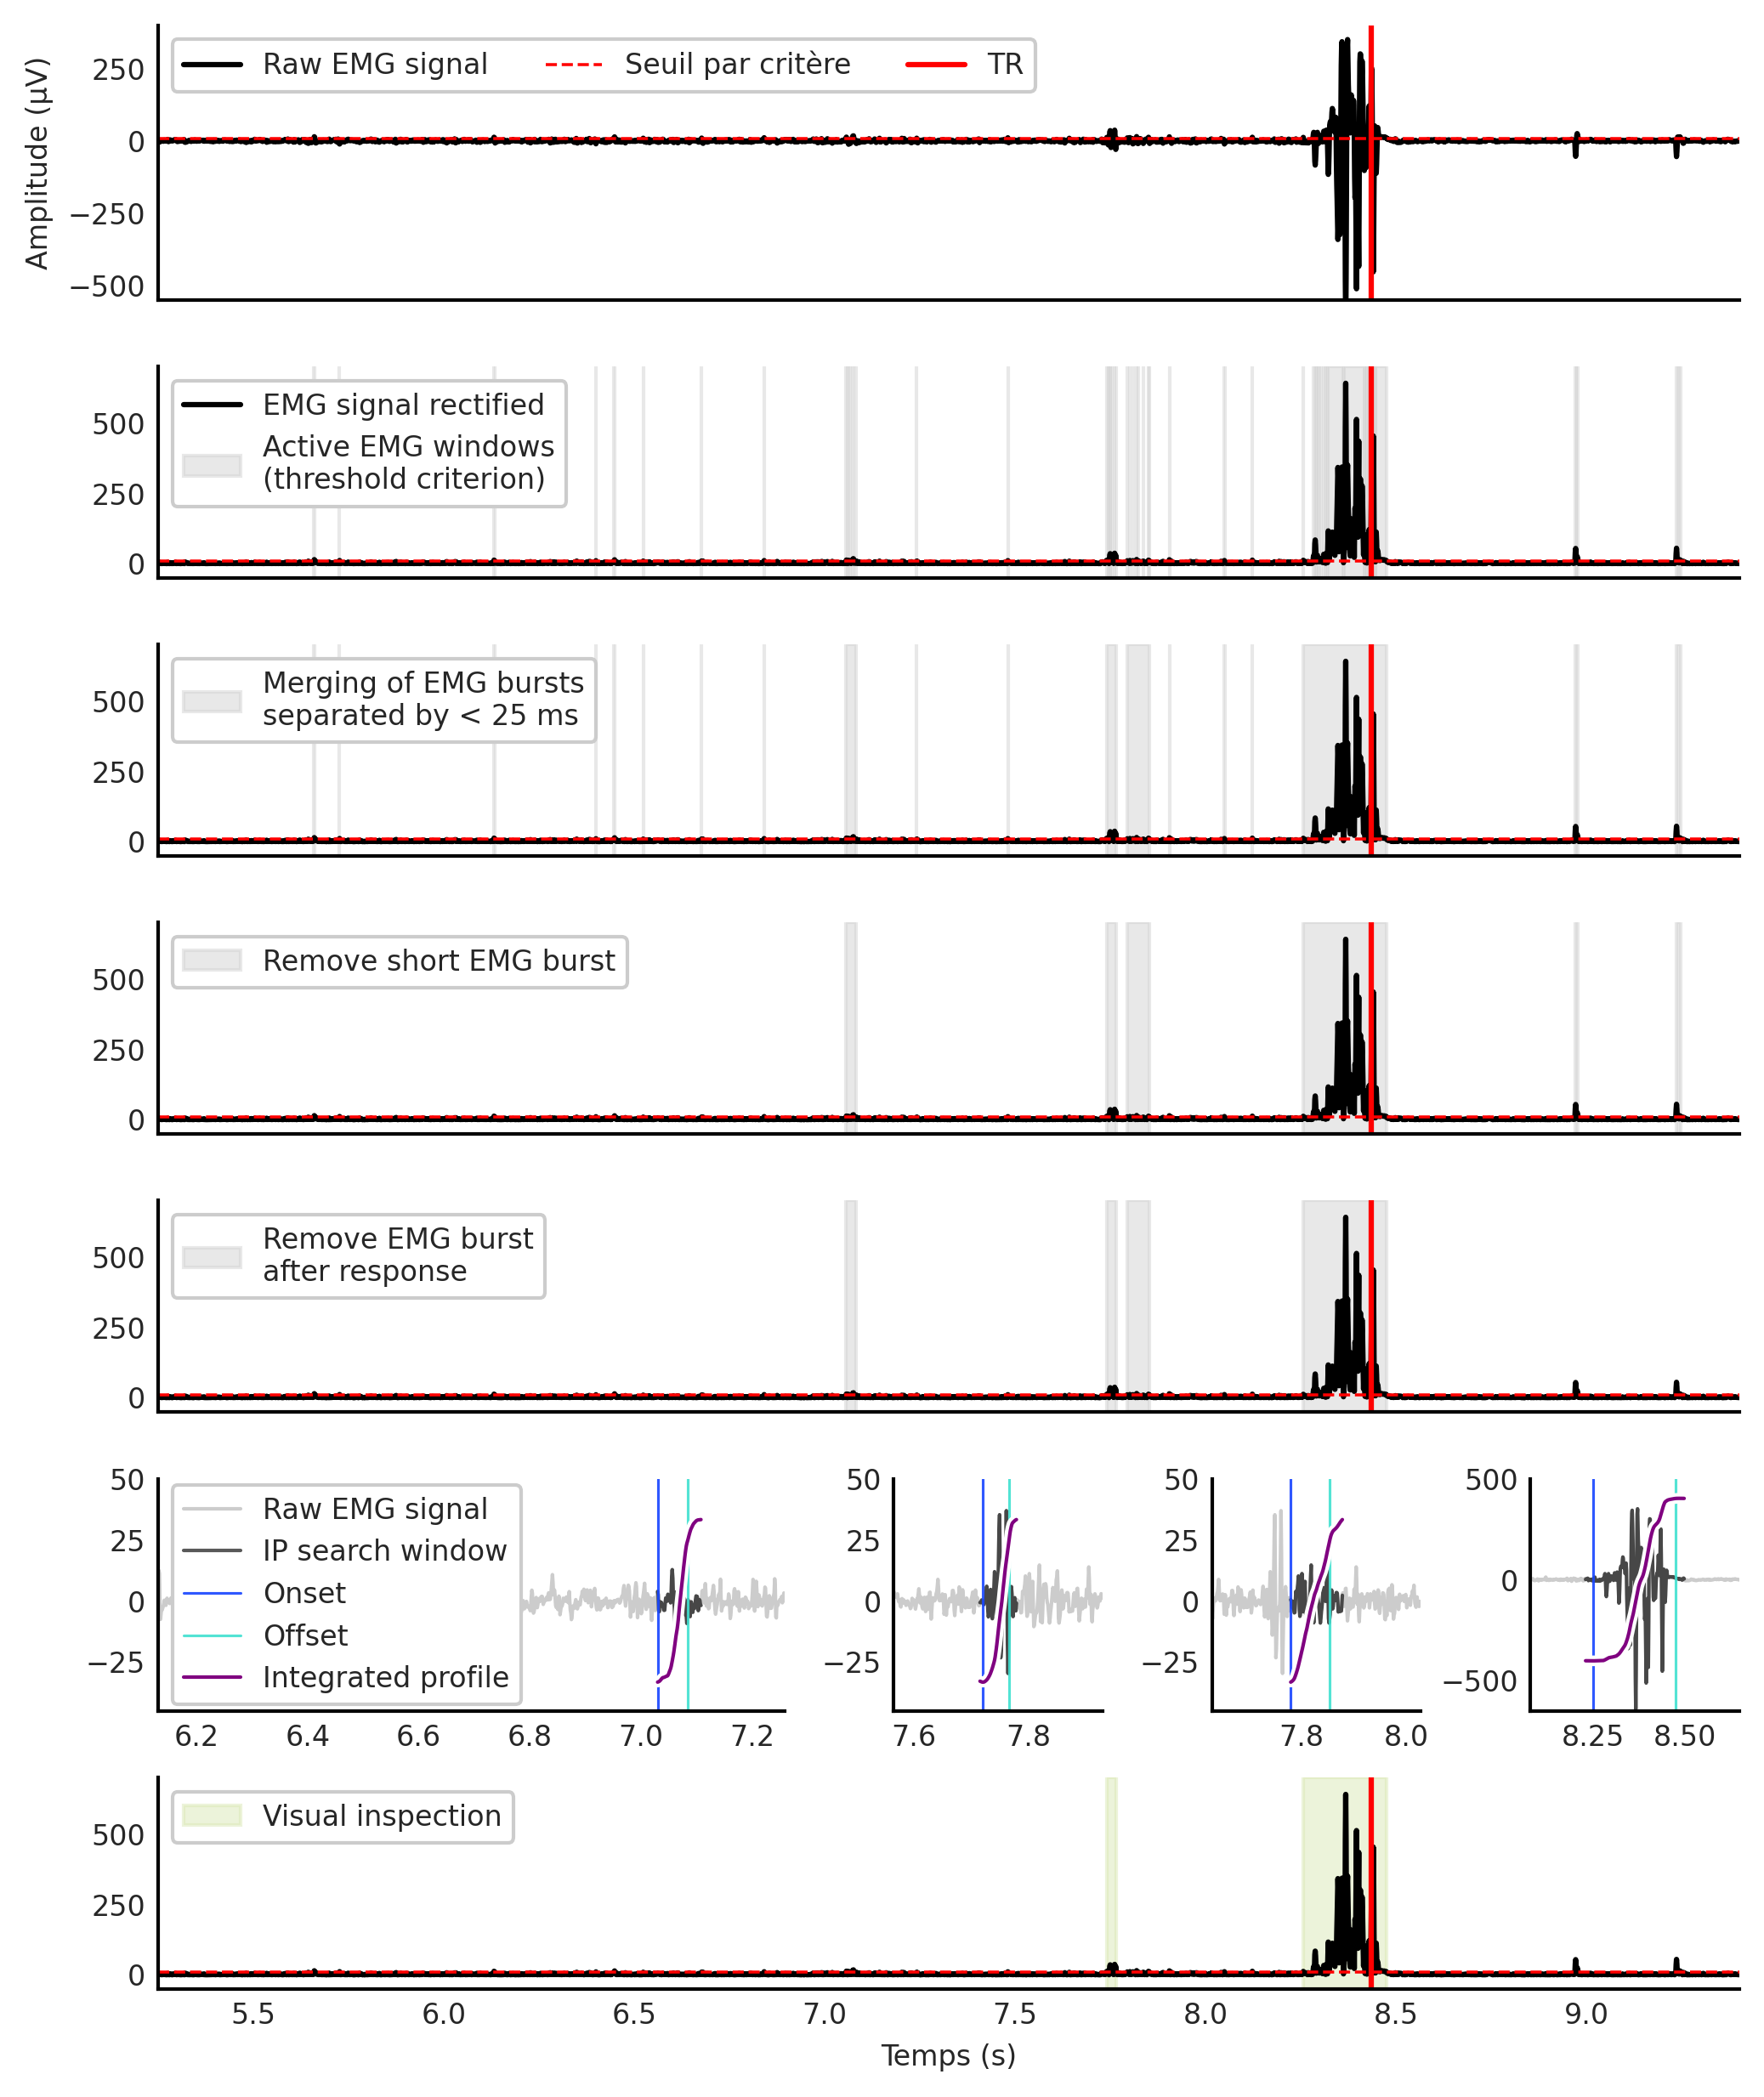

In [19]:
# -------------------------------------------------------------------------
# Plot result of EMG detection + IP row
# -------------------------------------------------------------------------

chan = 0 if chan_resp_left else 1
signal_plot = sig_rect[chan, :]
rt_time = epochTime[int(resp_latency)]

fig = plt.figure(figsize=(8, 10), dpi=300)

gs = fig.add_gridspec(
    7, 1,
    height_ratios=[0.65, 0.5, 0.5, 0.5, 0.5, 0.55, 0.5],
    hspace=0.3
)

axes = [None] * 7

# Main vertical axes, except row 5
for i in [0, 1, 2, 3, 4, 6]:
    if i == 0:
        axes[i] = fig.add_subplot(gs[i, 0])
    else:
        axes[i] = fig.add_subplot(gs[i, 0], sharex=axes[0])

# Row 5 split into 4 horizontal axes
ip_gs = gs[5, 0].subgridspec(1, 4, width_ratios=[3, 1, 1, 1], wspace=0.35)
ip_axes = [fig.add_subplot(ip_gs[0, j]) for j in range(4)]

list_win = [None, wins_raw, wins_merged, wins_pruned, wins_final, None, win_visual]
list_label = [
    "Raw EMG signal",
    "Active EMG windows\n(threshold criterion)",
    "Merging of EMG bursts\nseparated by < 25 ms",
    "Remove short EMG burst",
    "Remove EMG burst\nafter response",
    None,
    "Visual inspection"
]

# list_label = [
#     "Filtered bipolar EMG signal", #"Signal EMG bipolaire filtré",
#     "Active EMG window\n(threshold criterion)",
#     "Fusion des activités EMG\n rapprochées (< 25 ms)",
#     "Supprimer les activitées EMG courtes",
#     "Merging and removal brief\nand post-response activations", #"Supprimer les activitées EMG\naprès la réponse",
#     None,
#     "Visual inspection"
# ]

# list_colors = ["", "lightgrey", "khaki", "moccasin", "lightblue", None, "#dbe8b6ff"]
list_colors = ["", "lightgrey", "lightgrey", "lightgrey", "lightgrey", None, "#dbe8b6ff"]


for i in [0, 1, 2, 3, 4, 6]:
    if i == 0:
        axes[i].plot(epochTime, sig_raw[chan, :], color="black", label=list_label[i])
        axes[i].set_ylim([-550, 400])
    else:
        win = list_win[i]
        axes[i].plot(epochTime, signal_plot, color="black", label="EMG signal rectified" if i == 1 else None)

        for idx, (start, end) in enumerate(win[chan]):
            axes[i].axvspan(epochTime[start], epochTime[end - 1], color=list_colors[i], alpha=0.5, label=list_label[i] if idx == 0 else None)

        axes[i].set_ylim([-50, global_max + 250])

    axes[i].axhline(criterion[chan], color="red", linestyle="dashed", lw=0.85, label="Seuil par critère" if i == 0 else None)
    axes[i].set_xlim([5.25, 9.4])

    if i == 0:
        axes[i].set_ylabel("Amplitude (µV)", fontsize=8)

    axes[i].axvline(rt_time, color="red", linestyle="-", label="TR" if i == 0 else None)
    axes[i].legend(loc="upper left", frameon=True, fontsize=8, facecolor="white", framealpha=1, ncol=3 if i == 0 else 1)

for i in [0, 1, 2, 3, 4, 6]:
    axes[i].tick_params(axis="y", labelsize=8)
    axes[i].tick_params(axis="x", labelsize=8)

# Draw IP plots in row 5
ip_handles, ip_labels = plot_ip_on_axes(ip_axes, wins_final=wins_final, show_indices=False)

# Legend inside the fourth IP subplot
ip_axes[0].legend(ip_handles, ip_labels, loc="center left",
                   frameon=True, fontsize=8, facecolor="white", framealpha=1, ncol=1)

axes[6].set_xlabel("Temps (s)", fontsize=8)

# Delete xticks
for i in [0, 1, 2, 3, 4]:
    axes[i].tick_params(axis="x", labelbottom=False)


plt.tight_layout()
plt.show()

### 2.5. Automatic detection for all trials

The previous sections illustrated each step of the onset/offset detection procedure for one example trial.

In practice, the automatic detection is applied to all trials and both EMG channels. Detected EMG onsets and offsets are then added to the event structure using codes `350` and `351`, respectively.

These automatically detected markers will subsequently be visually inspected and manually corrected when necessary.

In [20]:
# -------------------------------------------------------------------------
# Automatic EMG onset/offset detection for all trials
# -------------------------------------------------------------------------

thEMG_raw = [7, 7]
lowest_delay = 0.025
smallest_burst = 3

useRaw = True
useTkeo = False

t0 = emg.findTimes(0, epochTime)

onset = []
onset_chan = []
offset = []
offset_chan = []

for e in range(epEvts.nbTrials()):
    for c in [0, 1]:

        current_signal = dataEpochs[e, c, :]

        onsets, offsets = emg.getOnsets(
            current_signal,
            epochTime,
            sf=epEvts.sf,
            thRaw=thEMG_raw[c],
            useRaw=useRaw,
            time_limitRaw=lowest_delay,
            min_samplesRaw=smallest_burst,
            varying_minRaw=1,
            mBlRaw=None,
            stBlRaw=None,
            useTkeo=useTkeo
        )

        onsets = np.asarray(onsets, dtype=int)
        offsets = np.asarray(offsets, dtype=int)

        # Remove bursts starting before stimulus onset
        keep = onsets > t0
        onsets = onsets[keep]
        offsets = offsets[keep]

        # Find first response after stimulus onset
        stim = epEvts.listEvtsTrials[e].findEvents(code=list(trigg_stim_id))
        resp = epEvts.listEvtsTrials[e].findEvents(code=list(trigg_resp_id.values()))
        resp_after_stim = resp[resp > stim[0]]

        if len(resp_after_stim) > 0:
            resp_latency = epEvts.listEvtsTrials[e].Latency.sample[resp_after_stim[0]]
        else:
            resp_latency = int(tmax * epEvts.sf)

        # Remove bursts starting after the response
        keep = onsets < resp_latency
        onsets = onsets[keep]
        offsets = offsets[keep]

        # Convert epoch-relative samples to continuous samples
        onset.extend(onsets + int(epEvts.tmin.sample[e]))
        onset_chan.extend([c] * len(onsets))

        offset.extend(offsets + int(epEvts.tmin.sample[e]))
        offset_chan.extend([c] * len(offsets))


# -------------------------------------------------------------------------
# Add EMG markers to the original event structure
# -------------------------------------------------------------------------

evtOnsets = Events(
    sample=onset,
    chan=onset_chan,
    code=[trigg_emg_id["onset"]] * len(onset),
    sf=epEvts.sf
)

evtOffsets = Events(
    sample=offset,
    chan=offset_chan,
    code=[trigg_emg_id["offset"]] * len(offset),
    sf=epEvts.sf
)

auto_events = events.copyEvents()
auto_events.addEvents(evtOnsets)
auto_events.addEvents(evtOffsets)

# Segment again, now including EMG onset/offset markers
epEvts_auto = auto_events.segment(
    codeT0=list(trigg_stim_id),
    tmin=tmin,
    tmax=tmax
)


# -------------------------------------------------------------------------
# Remove markers belonging to the following trial
# -------------------------------------------------------------------------

for e in range(epEvts_auto.nbTrials()):

    code = epEvts_auto.listEvtsTrials[e].code
    chan = epEvts_auto.listEvtsTrials[e].chan
    time = epEvts_auto.listEvtsTrials[e].Latency.time

    endIdx = evt.idxEndEvent(
        code,
        chan,
        time,
        list(trigg_stim_id),
        trigg_resp_id.values(),
        onsetCodes=trigg_emg_id["onset"],
        offsetCodes=trigg_emg_id["offset"],
        minStim=1,
        maxStim=1,
        minResp=0,
        maxResp=1,
        stop_after_response=False,
        stop_after_offset=True
    )

    epEvts_auto.listEvtsTrials[e].delEvents(
        range(
            endIdx + 1,
            epEvts_auto.listEvtsTrials[e].nbEvents()
        ),
        printDelEvt=False
    )


print(
    f"> Automatic detection completed: "
    f"{len(onset)} onsets and {len(offset)} offsets detected."
)


Found 240 epoch(s).
> Automatic detection completed: 1372 onsets and 1372 offsets detected.


In [21]:
# -------------------------------------------------------------------------
# Save automatically detected events without overwriting existing files
# -------------------------------------------------------------------------

segmented_folder = os.path.join(current, "data_example", "EMG_processing", "processed_data_STEP2", "segmented")
continuous_folder = os.path.join(current, "data_example", "EMG_processing", "processed_data_STEP2", "continuous")

os.makedirs(segmented_folder, exist_ok=True)
os.makedirs(continuous_folder, exist_ok=True)

segmented_file = os.path.join(segmented_folder, nameSubj + "_segmentedEvts.csv")
continuous_file = os.path.join(continuous_folder, nameSubj + "_continuousEvts.csv")

if not os.path.exists(segmented_file) and not os.path.exists(continuous_file):
    epEvts_auto.saveAsCSV(segmented_file)
    epEvts_auto.saveContinuousAsCSV(continuous_file)
    print(">> Automatic segmented and continuous events saved.")
else:
    print(">> One or both event files already exist: automatic files were not overwritten.")

>> One or both event files already exist: automatic files were not overwritten.


## 3. Visual inspection and manual correction

Automatic EMG onset/offset detection should always be followed by visual inspection. Each trial and both EMG channels are inspected using the `vizEMG` interface. Automatically detected onset (`350`) and offset (`351`) markers can be manually moved, deleted, or added when necessary. Stimulus and response markers are not modified. 

The figure below illustrates the visual inspection interface used for manual validation.

### 3.1. Visual inspection interface

Example of the `vizEMG` interface used to visually inspect and manually correct automatically detected EMG onset and offset markers.

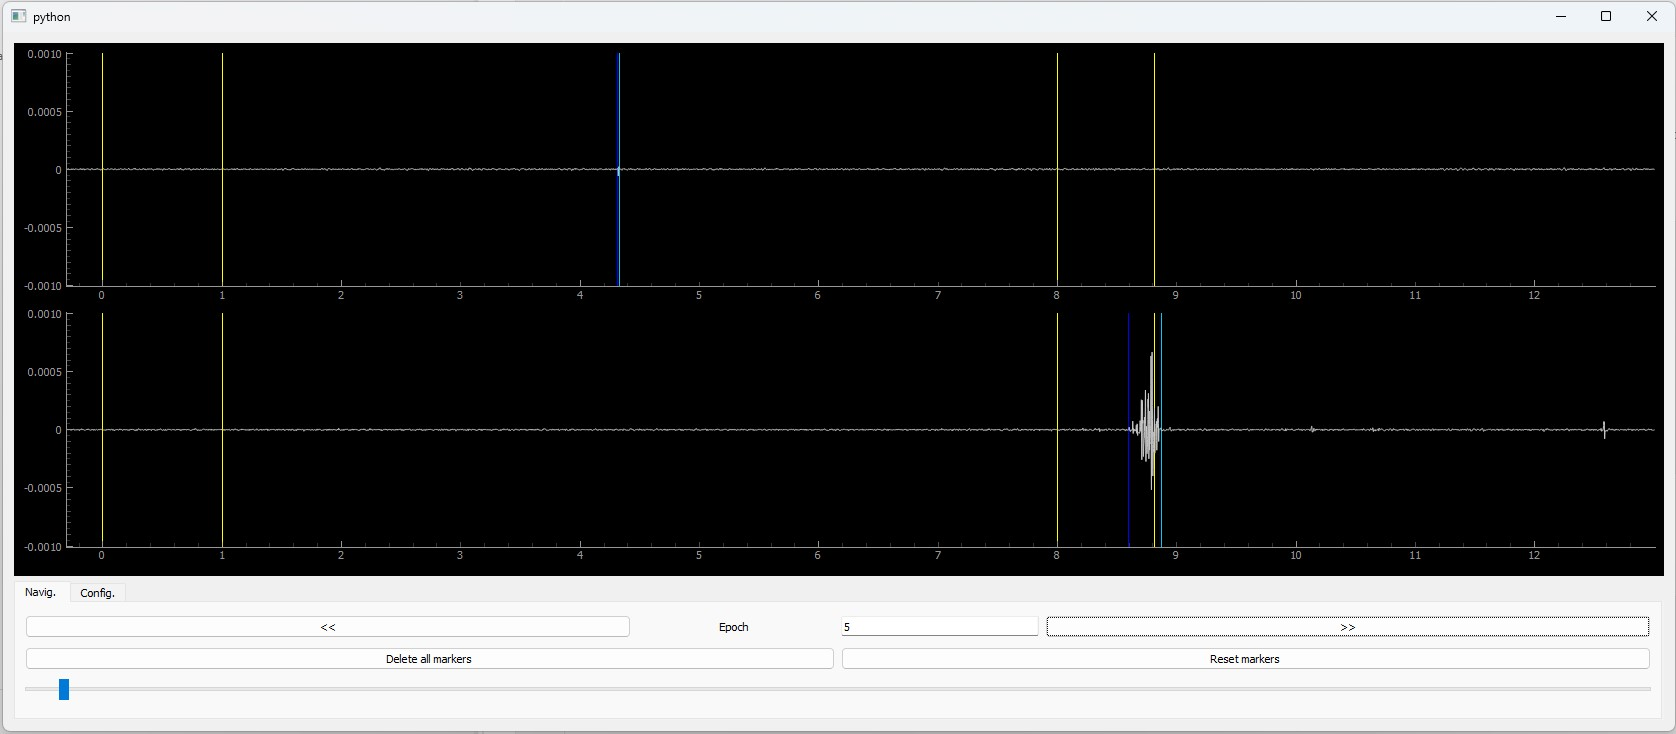

In [22]:
from IPython.display import Image, display

image_path = os.path.join(
    current,
    "figures",
    "vizEMG_visual_inspection_example.jpg"
)

display(
    Image(
        filename=image_path,
        width=2000
    )
)

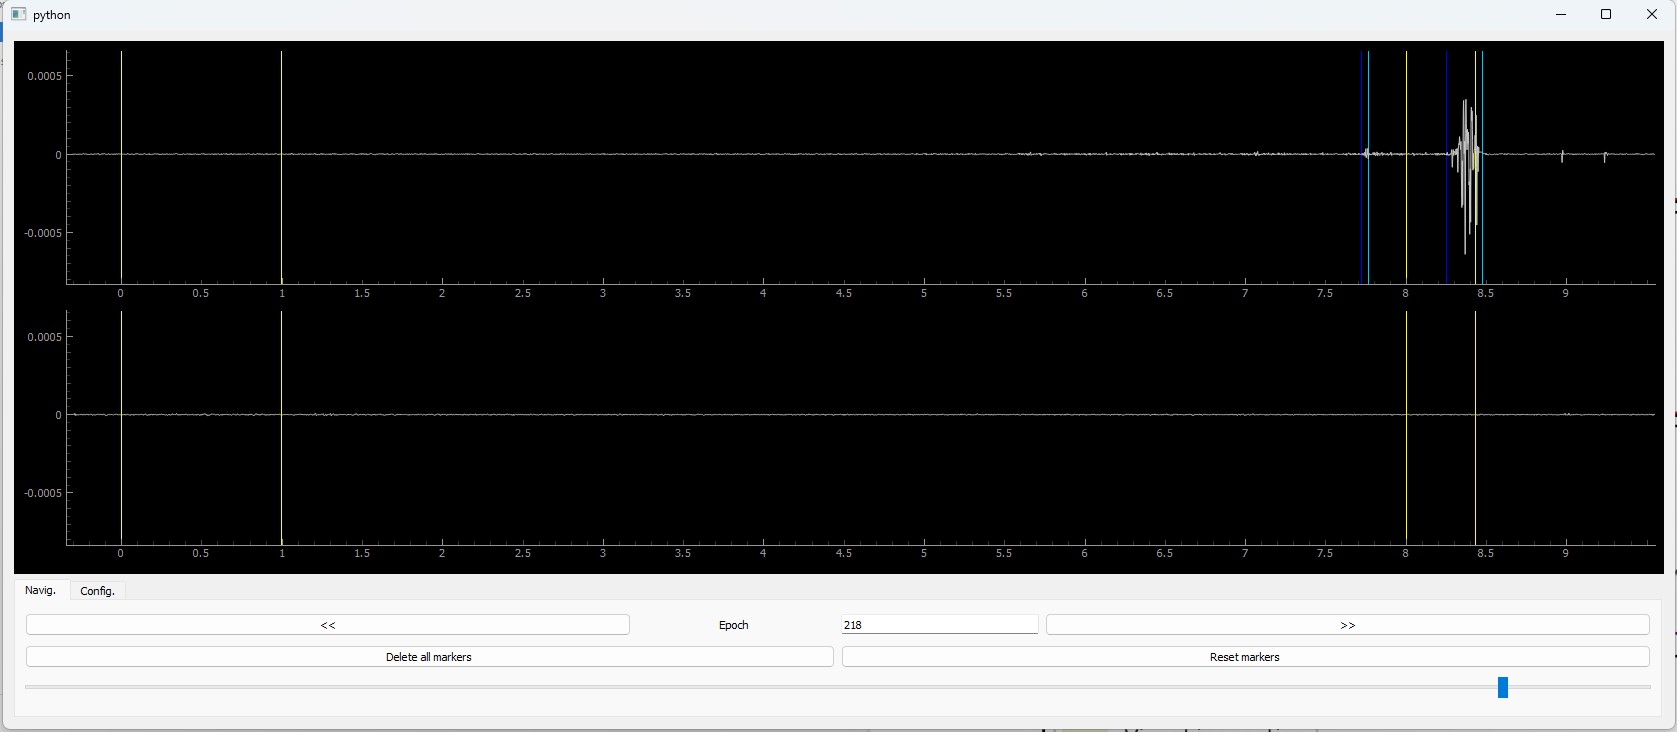

In [23]:
from IPython.display import Image, display

image_path = os.path.join(
    current,
    "figures",
    "viz_EMG_interface_trial218.jpg"
)

display(
    Image(
        filename=image_path,
        width=2000
    )
)

> **/!\ Warning — protect manual corrections**
>
> For actual data processing, it is strongly recommended to perform the visual inspection and manual correction step in a separate script from the automatic EMG detection pipeline.
>
> Once EMG onset/offset markers have been manually corrected, these corrections should be saved immediately. Re-running the automatic EMG detection on the same subject may regenerate the segmented event file and overwrite all previous manual corrections.
>
> For this reason, the automatic detection pipeline should **never replace an existing segmented file that may already contain manually validated corrections**.
>
> A recommended workflow is:
>
> 1. run automatic EMG detection once and save the automatically detected events;
> 2. perform visual inspection and manual correction in a separate script;
> 3. automatically save the manually validated segmented and continuous event files from this separate script;
> 4. do not re-run the automatic detection pipeline in a way that could replace these validated files.

### 3.2. Launch the visual inspection interface

The following code opens the interactive `vizEMG` interface. This step requires a local graphical Python environment (e.g., PyQt).

In [24]:
# -------------------------------------------------------------------------
# Launch vizEMG for manual inspection
# -------------------------------------------------------------------------

viz = vizEMG.VizApplication(sys.argv)

viz.loadData(
    dataEpochs,
    epochTime,
    epEvts_auto,
    codeMovable1=trigg_emg_id["onset"],
    codeMovable2=trigg_emg_id["offset"]
)

viz.show()

### 3.3. Save manually validated events

After visual inspection and manual correction, the final event markers are saved in two complementary formats:

- **segmented events**: event latencies relative to each stimulus-locked epoch;
- **continuous events**: event latencies relative to the original continuous recording.

These files contain the final manually validated EMG onset and offset markers.

In [25]:
# -------------------------------------------------------------------------
# Save manually validated onset/offset markers
# -------------------------------------------------------------------------

# Retrieve manually corrected events from vizEMG
vizEvts = viz.getEvents()

segmented_folder = os.path.join(current, "data_example", "EMG_processing", "processed_data_STEP2", "segmented")
continuous_folder = os.path.join(current, "data_example", "EMG_processing", "processed_data_STEP2", "continuous")

# Create folders if necessary
os.makedirs(segmented_folder, exist_ok=True)
os.makedirs(continuous_folder, exist_ok=True)

# Save segmented events
segmented_file = os.path.join(segmented_folder, nameSubj + "_segmentedEvts.csv")

vizEvts.saveAsCSV(segmented_file)

# Save continuous events
continuous_file = os.path.join(continuous_folder, nameSubj + "_continuousEvts.csv")

vizEvts.saveContinuousAsCSV(continuous_file)

print(">> Manual validation completed: segmented and continuous event files saved.")

Saving as segmented...
Saving as continuous...
Checking for duplicates in events...
0 event(s) removed.
>> Manual validation completed: segmented and continuous event files saved.


Thanks for reading, and enjoy working with your data.